In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

# Assumes this is run from the experiments directory with the scm package in the parent
sys.path.insert(0, '..')

from scm import SBMGenerator, CIC3Simulator
from scm import MultiRandomSeeding, MultiHighDegreeSeeding, CommunityFarthestFirstSeeding
from scm.analysis import (time_discounted_attainment, no_decay, exponential_decay,
                           deadweight, penetration)

# --- Global Parameters ---
N = 2000
CORE_SIZE = 50
C = 10
BETA = 0.05
BETA_DELTA = 0.1
T_MAX = 2000
NUM_TRIALS = 15
NUM_SEEDS_PER_CONTAGION = 1
# V = no_decay()
V = exponential_decay(0.05)

# --- Periphery Intra-Community Probability ---
P_PERIPH_INTRA = 0.3

# --- Sweep Parameters ---
GRID_RESOLUTION = 10

# Continuous sweep ranges for axes
SWEEPS = {
    'P_CC': np.linspace(0.3, 0.3, 1),    # Core density
    'P_PI': np.linspace(0.001, 0.3, GRID_RESOLUTION),  # Periphery inter-community density
    'P_CP': np.linspace(0.001, 0.3, GRID_RESOLUTION)   # Core-Periphery bridge
}

# Discrete values for the fixed third variable
DISCRETE = {
    'P_CC': [0.2, 0.5, 0.8],
    'P_PI': [0.05],
    'P_CP': [0.05]
}

# Unordered combinations: (fixed_var, y_axis_var, x_axis_var)
EXPERIMENTS = [
    # ('P_CP', 'P_CC', 'P_PI'),
    # ('P_PI', 'P_CC', 'P_CP'),
    ('P_CC', 'P_CP', 'P_PI')
]

LABELS = {
    'P_CC': "Core Density ($P_{intra}$)",
    'P_PI': "Periphery Inter-Density ($P_{inter}$)",
    'P_CP': "Core-Periphery Bridge ($P_{CP}$)"
}

STRATEGIES = {
    'Random': MultiRandomSeeding,
    'Farthest-First': CommunityFarthestFirstSeeding,
    'High-Degree': MultiHighDegreeSeeding,
}
STRAT_NAMES = list(STRATEGIES.keys())
STRAT_COLORS = {'Random': '#1f77b4', 'Farthest-First': '#2ca02c', 'High-Degree': '#d62728'}

In [8]:
def make_quotas_and_seeds(N_topo, C=C, seed_frac_divisor=5):
    base = N_topo // C
    rem = N_topo - base * C
    quotas = [base + 1] * rem + [base] * (C - rem)
    seeds = [NUM_SEEDS_PER_CONTAGION] * C
    return quotas, seeds

def make_core_periphery_kwargs(p_cc, p_pi, p_cp, N=N, core_size=CORE_SIZE,
                                p_periph_intra=P_PERIPH_INTRA):
    periph_K = 9
    periph_size = (N - core_size) // periph_K
    sizes = [core_size] + [periph_size] * periph_K
    K = len(sizes)
    
    P = np.zeros((K, K))
    P[0, 0] = p_cc
    
    for i in range(1, K):
        P[0, i] = p_cp
        P[i, 0] = p_cp
        P[i, i] = p_periph_intra       # Intra-community (diagonal)
        for j in range(i + 1, K):
            P[i, j] = p_pi              # Inter-community (off-diagonal)
            P[j, i] = p_pi
            
    T = np.zeros(K)
    T[0] = p_cc * 0.25 
    T[1:] = p_periph_intra * 0.25       # Triangles scale with intra-community density
    
    return {
        "community_sizes": sizes,
        "block_matrix": P.tolist(),
        "triangle_block_probs": T.tolist()
    }

def evaluate_strategy(strat_cls, topo_links, topo_triangles, quotas, seeds):
    "Run one strategy and return (A_g_td, D_g, P_g)."
    seeder = strat_cls(
        N=N, num_seeds_per_contagion=seeds,
        links=topo_links, triangles=topo_triangles,
    )
    initial_infected = seeder.seed()
    
    sim = CIC3Simulator(
        links=topo_links, triangles=topo_triangles,
        initial_infected_per_contagion=initial_infected,
        betas=[BETA] * C, beta_deltas=[BETA_DELTA] * C, quotas=quotas,
    )
    sim.run(T_MAX)
    
    _, A_g_td = time_discounted_attainment(sim.infected_by, sim.infection_times, quotas, V)
    _, D_g = deadweight(sim.infected_by, quotas)
    _, P_g = penetration(topo_links, sim.infected_by, initial_infected)
    
    return A_g_td, D_g, P_g

In [9]:
os.makedirs("results", exist_ok=True)
results_file = "../results/cic3_combinatorial_sweep.pkl"

if os.path.exists(results_file):
    print("Loading existing sweep results...")
    with open(results_file, "rb") as f:
        all_results = pickle.load(f)
else:
    all_results = {}
    print("Running combinatorial parameter sweep. This will take a moment...")
    
    for fixed_var, y_var, x_var in EXPERIMENTS:
        print(f"\n=== Sweeping {y_var} (Y) and {x_var} (X) | Fixing {fixed_var} ===")
        
        fixed_vals = DISCRETE[fixed_var]
        y_vals = SWEEPS[y_var]
        x_vals = SWEEPS[x_var]
        
        # Per-trial raw data keyed by (strat_name, metric_name)
        # metric_names: 'ag_td', 'dw', 'pen'
        # Each value: list of (p_cp - p_pi, metric_value) for line charts
        raw_data = defaultdict(list)
        
        # Mean tensors for heatmaps: [fixed_idx, y_idx, x_idx]
        tensors = {}
        for sname in STRAT_NAMES:
            for metric in ['ag_td', 'dw', 'pen']:
                tensors[f"{sname}_{metric}"] = np.zeros((3, GRID_RESOLUTION, GRID_RESOLUTION))
        
        for i, fixed_val in enumerate(fixed_vals):
            # print(f"  [{i+1}/1] Fixed {fixed_var} = {fixed_val}")
            for y_idx, y_val in enumerate(y_vals):
                for x_idx, x_val in enumerate(x_vals):
                    print(f"    [{y_idx*len(x_vals)+x_idx+1}/{len(y_vals)*len(x_vals)}] {y_var} = {y_val}, {x_var} = {x_val}")
                    
                    current_params = {fixed_var: fixed_val, y_var: y_val, x_var: x_val}
                    sbm_kwargs = make_core_periphery_kwargs(
                        p_cc=current_params['P_CC'], 
                        p_pi=current_params['P_PI'], 
                        p_cp=current_params['P_CP']
                    )
                    
                    # Diff for line-chart x-axis
                    p_diff = current_params['P_CP'] - current_params['P_PI']
                    
                    trial_results = {sname: {'ag_td': [], 'dw': [], 'pen': []}
                                     for sname in STRAT_NAMES}
                    
                    for _ in range(NUM_TRIALS):
                        gen = SBMGenerator(**sbm_kwargs)
                        links, triangles = gen.generate()
                        quotas, seeds = make_quotas_and_seeds(len(links))
                        
                        for sname, scls in STRATEGIES.items():
                            ag_td, dw, pen = evaluate_strategy(scls, links, triangles, quotas, seeds)
                            trial_results[sname]['ag_td'].append(ag_td)
                            trial_results[sname]['dw'].append(dw)
                            trial_results[sname]['pen'].append(pen)
                            raw_data[(sname, 'ag_td')].append((p_diff, ag_td))
                            raw_data[(sname, 'dw')].append((p_diff, dw))
                            raw_data[(sname, 'pen')].append((p_diff, pen))
                    
                    # Store mean tensors
                    for sname in STRAT_NAMES:
                        for metric in ['ag_td', 'dw', 'pen']:
                            tensors[f"{sname}_{metric}"][i, y_idx, x_idx] = np.mean(trial_results[sname][metric])
        
        # Store tensors in results
        for key, tensor in tensors.items():
            all_results[f"fixed_{fixed_var}_{key}"] = tensor
        
        # Store raw data for line charts
        all_results[f"fixed_{fixed_var}_raw"] = dict(raw_data)
        
        # Save incrementally
        with open(results_file, "wb") as f:
            pickle.dump(all_results, f)
            
    print("\nCombinatorial sweep complete and saved.")

Running combinatorial parameter sweep. This will take a moment...

=== Sweeping P_CP (Y) and P_PI (X) | Fixing P_CC ===
    [1/100] P_CP = 0.001, P_PI = 0.001
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 4089
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 15726
Realized k_avg = 48.74, k_delta_avg = 94.36
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 4045
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 15710
Realized k_avg = 48.74, k_delta_avg = 94.26
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 4005
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 15623
Realized k_avg = 48.69, k_delta_avg = 93.74
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 3982
Sampling triangles per block-triple
SBM triangles sampled (through block 9,9,9): 15701
Realized k_avg = 48.74, k_delta_avg = 94.21
Sampling edges per bl

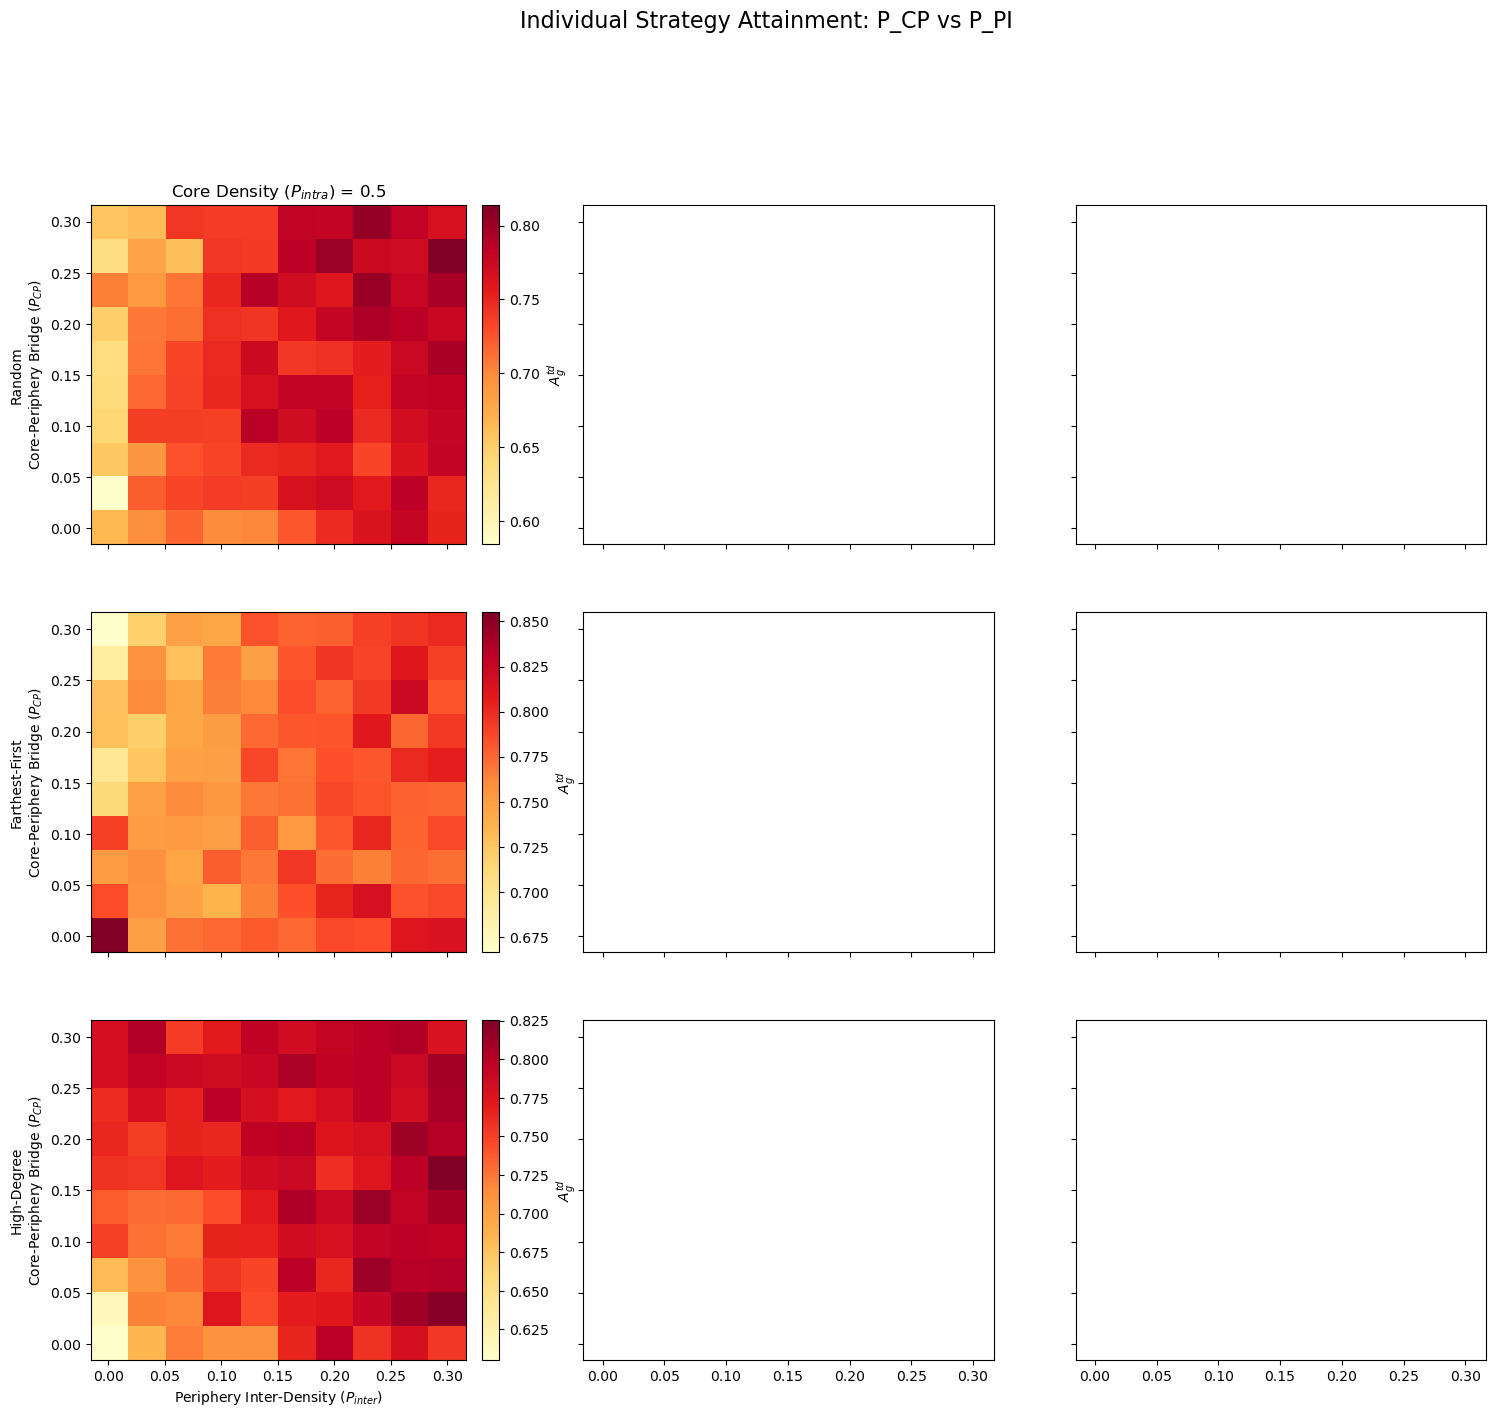

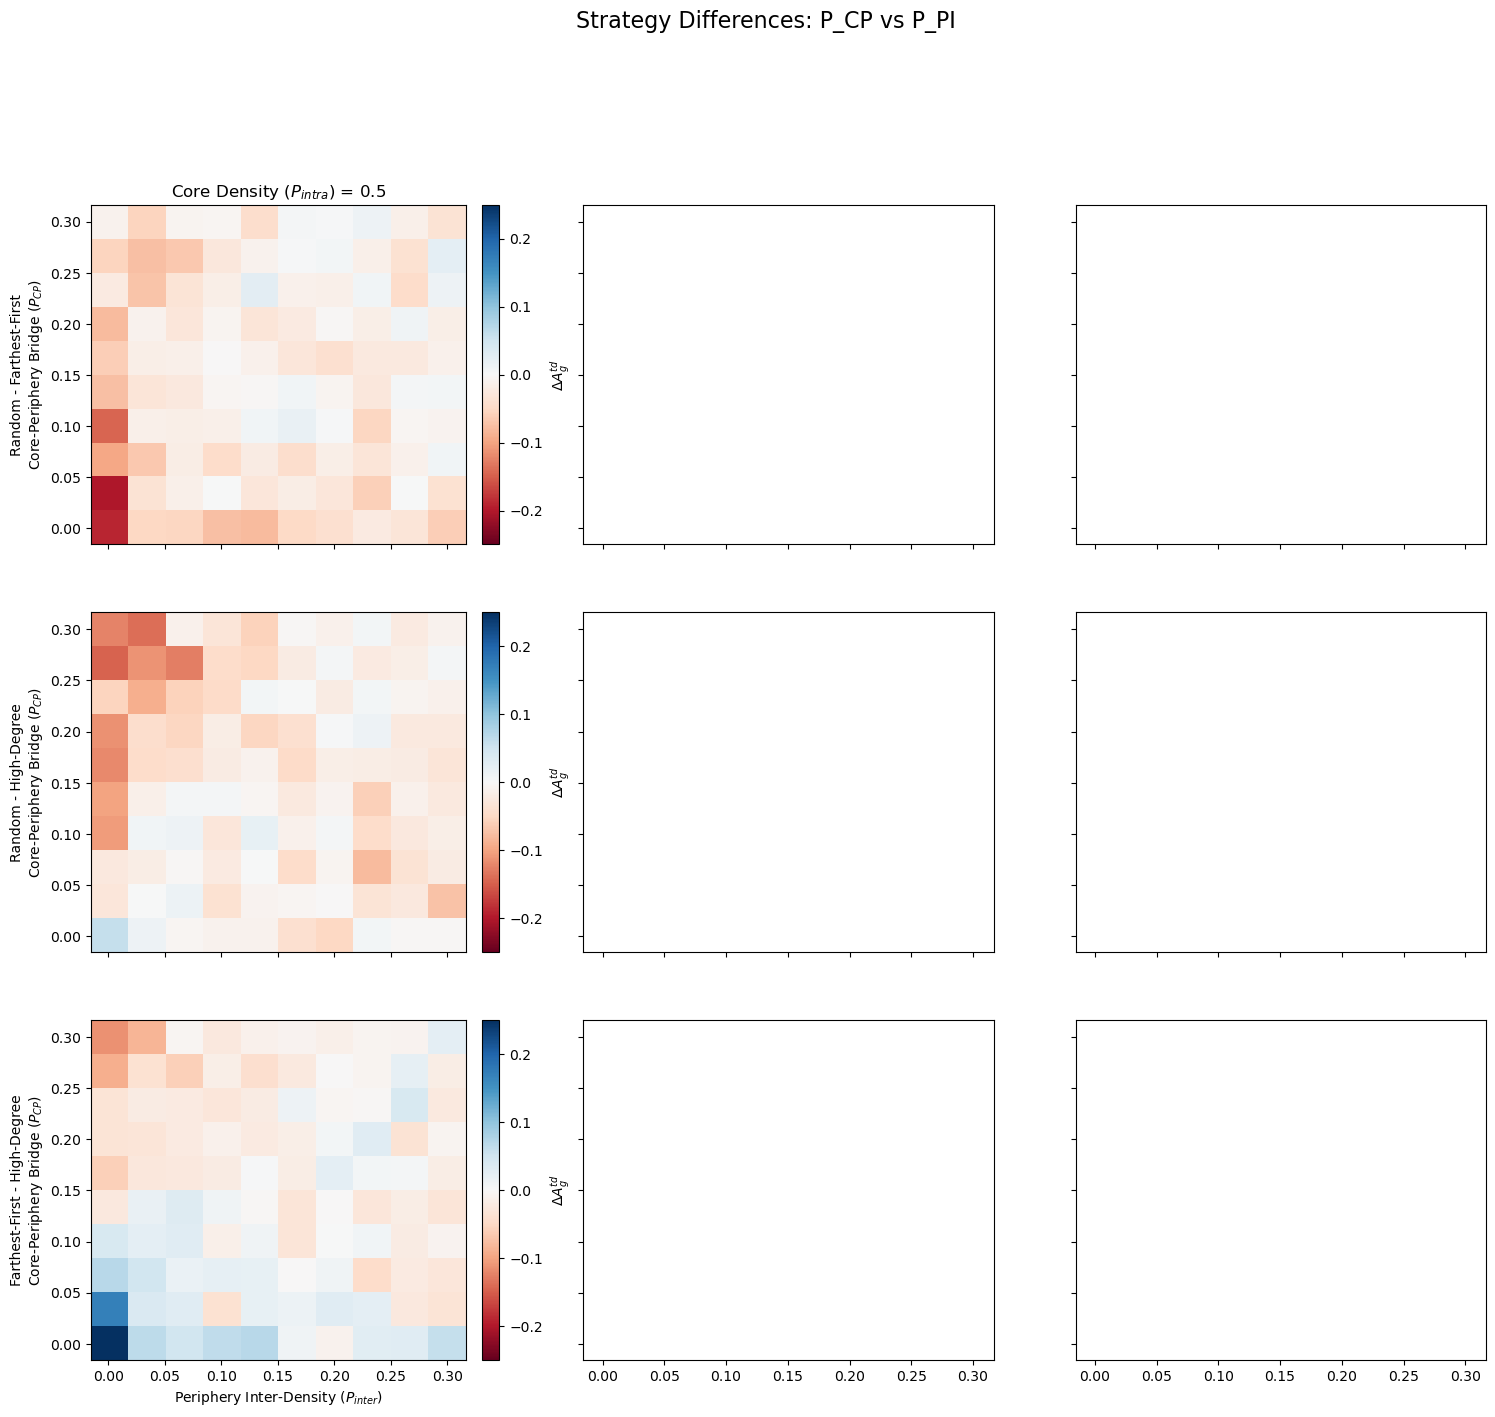

In [ ]:
for fixed_var, y_var, x_var in EXPERIMENTS:
    fixed_vals = DISCRETE[fixed_var]
    X_mesh, Y_mesh = np.meshgrid(SWEEPS[x_var], SWEEPS[y_var])
    
    # Load individual strategy tensors
    strat_tensors = {}
    for sname in STRAT_NAMES:
        strat_tensors[sname] = all_results[f"fixed_{fixed_var}_{sname}_ag_td"]
    
    # Compute delta tensors
    deltas = {
        'Random - Farthest-First': strat_tensors['Random'] - strat_tensors['Farthest-First'],
        'Random - High-Degree': strat_tensors['Random'] - strat_tensors['High-Degree'],
        'Farthest-First - High-Degree': strat_tensors['Farthest-First'] - strat_tensors['High-Degree'],
    }
    
    # --- Figure 1: Individual strategy heatmaps ---
    raw_vmin = min(t.min() for t in strat_tensors.values())
    raw_vmax = max(t.max() for t in strat_tensors.values())
    
    fig, axes = plt.subplots(len(STRAT_NAMES), 3, figsize=(18, 5 * len(STRAT_NAMES)),
                              sharex=True, sharey=True)
    
    for row_idx, sname in enumerate(STRAT_NAMES):
        tensor = strat_tensors[sname]
        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            val = fixed_vals[col_idx]
            Z = tensor[col_idx]
            
            mesh = ax.pcolormesh(X_mesh, Y_mesh, Z, cmap='YlOrRd',
                                 shading='nearest')
            
            if row_idx == 0:
                ax.set_title(f"{LABELS[fixed_var]} = {val}")
            if col_idx == 0:
                ax.set_ylabel(f"{sname}\n{LABELS[y_var]}")
            if row_idx == len(STRAT_NAMES) - 1:
                ax.set_xlabel(LABELS[x_var])
            
            cb = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("$A_g^{td}$")
    
    fig.suptitle(f"Individual Strategy Attainment: {y_var} vs {x_var}", fontsize=16, y=1.01)
    fig.savefig(f"../figures/cic3_sweep_fixed_{fixed_var}_individual.png", dpi=200, bbox_inches="tight")
    plt.show()
    
    # --- Figure 2: Delta heatmaps ---
    delta_abs_max = max(max(np.abs(d).max(), 0.01) for d in deltas.values())
    
    fig, axes = plt.subplots(len(deltas), 3, figsize=(18, 5 * len(deltas)),
                              sharex=True, sharey=True)
    
    for row_idx, (delta_name, delta_tensor) in enumerate(deltas.items()):
        for col_idx in range(3):
            ax = axes[row_idx, col_idx]
            val = fixed_vals[col_idx]
            Z = delta_tensor[col_idx]
            
            mesh = ax.pcolormesh(X_mesh, Y_mesh, Z, cmap='RdBu',
                                 vmin=-delta_abs_max, vmax=delta_abs_max, shading='nearest')
            
            if row_idx == 0:
                ax.set_title(f"{LABELS[fixed_var]} = {val}")
            if col_idx == 0:
                ax.set_ylabel(f"{delta_name}\n{LABELS[y_var]}")
            if row_idx == len(deltas) - 1:
                ax.set_xlabel(LABELS[x_var])
            
            cb = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("$\\Delta A_g^{td}$")
    
    fig.suptitle(f"Strategy Differences: {y_var} vs {x_var}", fontsize=16, y=1.01)
    fig.savefig(f"../figures/cic3_sweep_fixed_{fixed_var}_deltas.png", dpi=200, bbox_inches="tight")
    plt.show()

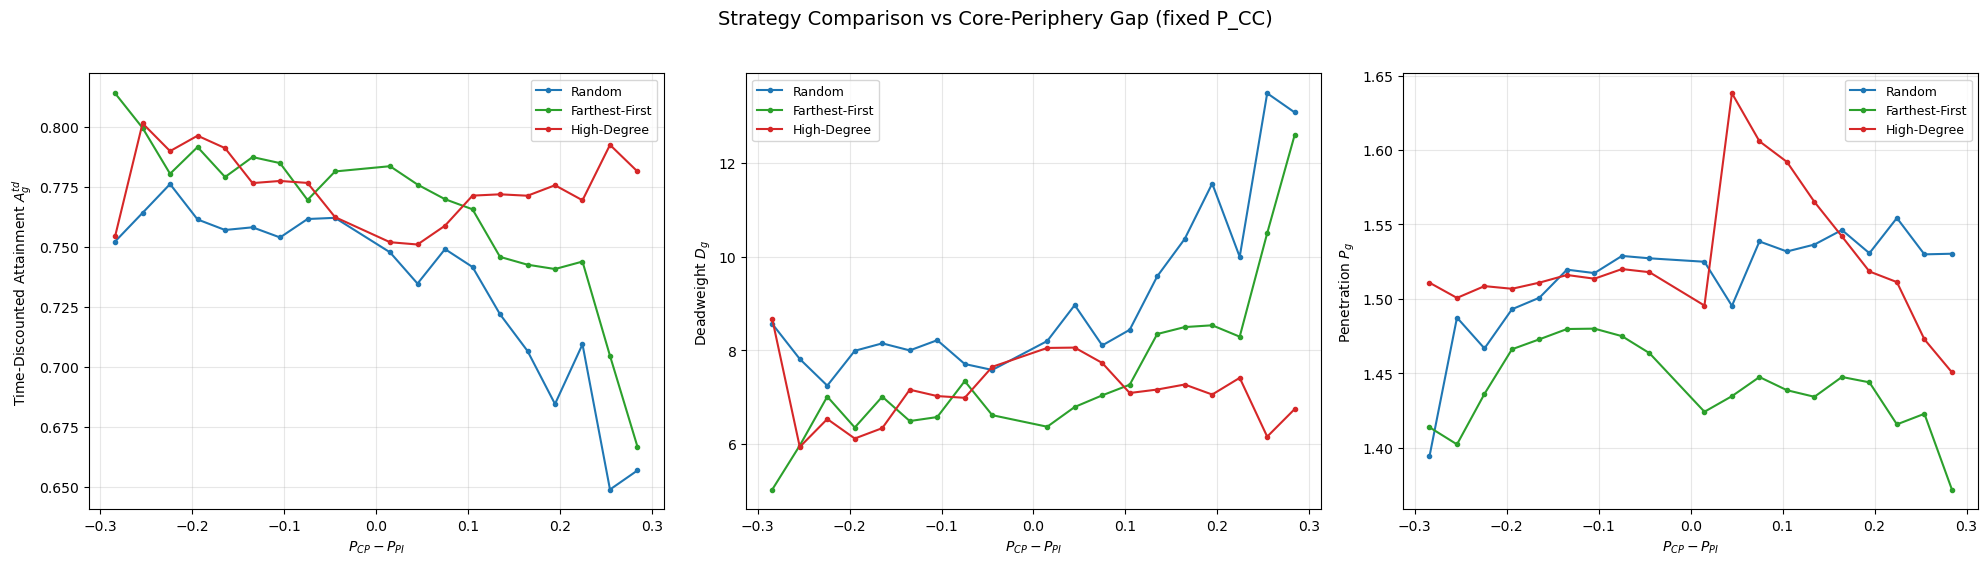

In [18]:
for fixed_var, y_var, x_var in EXPERIMENTS:
    raw_data = all_results[f"fixed_{fixed_var}_raw"]
    
    metric_info = [
        ('ag_td', "Time-Discounted Attainment $A_g^{td}$", "cic3_linechart_attainment"),
        ('dw',    "Deadweight $D_g$",                        "cic3_linechart_deadweight"),
        ('pen',   "Penetration $P_g$",                       "cic3_linechart_penetration"),
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
    
    for ax_idx, (metric, ylabel, _) in enumerate(metric_info):
        ax = axes[ax_idx]
        
        for sname in STRAT_NAMES:
            pairs = raw_data[(sname, metric)]
            diffs = [p[0] for p in pairs]
            vals  = [p[1] for p in pairs]
            
            # Bin by P_CP - P_PI and compute mean + std per bin
            diffs_arr = np.array(diffs)
            vals_arr = np.array(vals)
            bins = np.linspace(diffs_arr.min() - 1e-9, diffs_arr.max() + 1e-9, 21)
            bin_centers = 0.5 * (bins[:-1] + bins[1:])
            bin_means = []
            bin_stds = []
            bin_x = []
            for b in range(len(bin_centers)):
                mask = (diffs_arr >= bins[b]) & (diffs_arr < bins[b+1])
                if mask.any():
                    bin_means.append(vals_arr[mask].mean())
                    bin_stds.append(vals_arr[mask].std())
                    bin_x.append(bin_centers[b])
            
            ax.errorbar(bin_x, bin_means, # yerr=bin_stds,
                        label=sname, color=STRAT_COLORS[sname],
                        marker='o', markersize=3, capsize=2, linewidth=1.5)
        
        ax.set_xlabel("$P_{CP} - P_{PI}$")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f"Strategy Comparison vs Core-Periphery Gap (fixed {fixed_var})", fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(f"../figures/cic3_sweep_fixed_{fixed_var}_linecharts.png", dpi=200, bbox_inches="tight")
    plt.show()